In [71]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [72]:

data = pd.read_csv("IRIS_TrainData.csv")
print("Instances per class:\n", data['species'].value_counts())
print(data.head())

Instances per class:
 species
Iris-setosa        40
Iris-versicolor    40
Name: count, dtype: int64
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


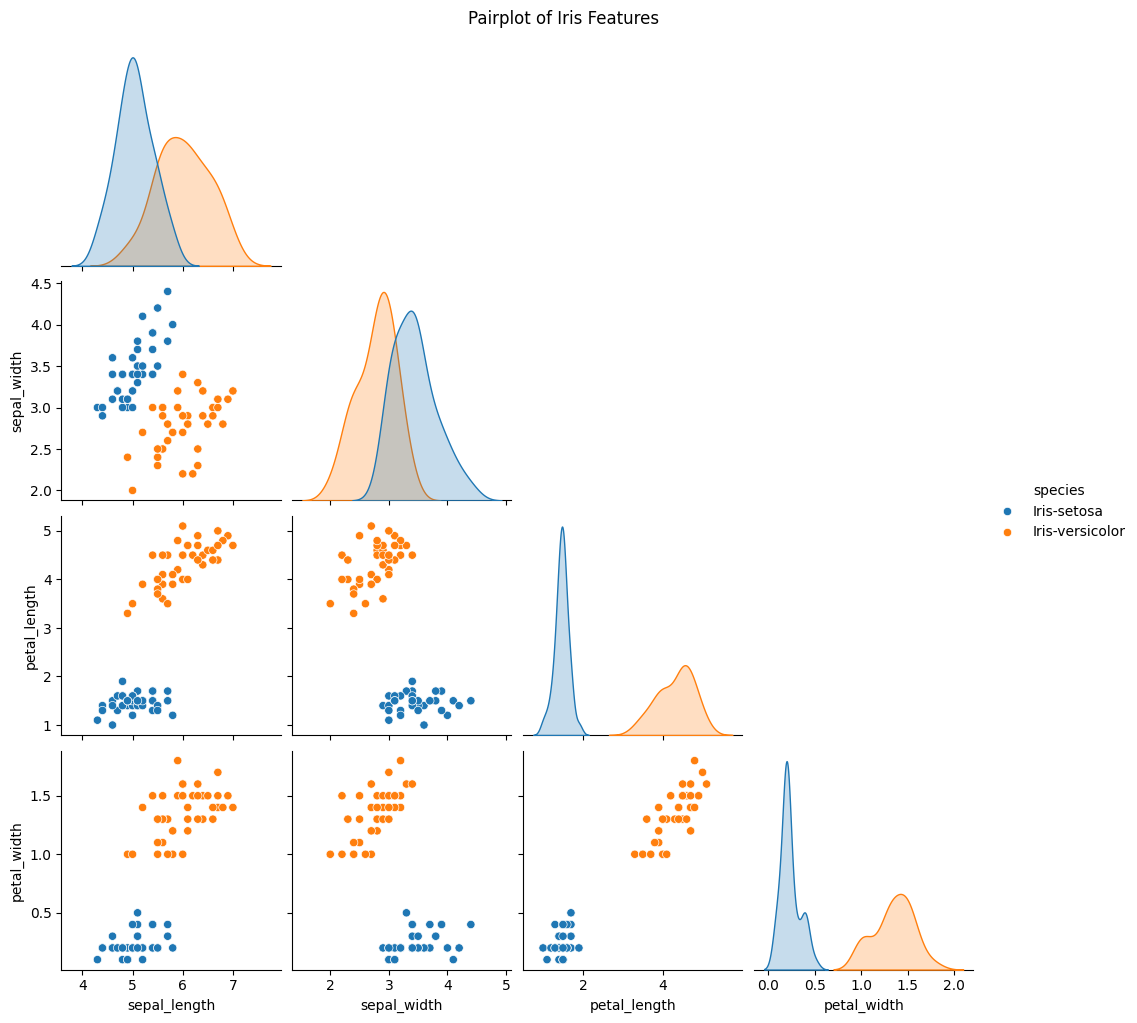

In [73]:
sns.pairplot(data, hue="species", corner=True)
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

In [74]:
encoder = {"Iris-setosa": 0.0001, "Iris-versicolor": 0.9999}
data['y_enc'] = data['species'].map(encoder)


In [75]:
X = data[['sepal_length','sepal_width','petal_length','petal_width']].values

In [76]:
X.shape

(80, 4)

In [77]:
y = data['y_enc']
y.shape

(80,)

In [78]:
y = data['y_enc'].values.reshape(-1,1)

In [79]:
y.shape

(80, 1)

In [80]:
scaler = StandardScaler()



In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2, stratify=y#mix 
)

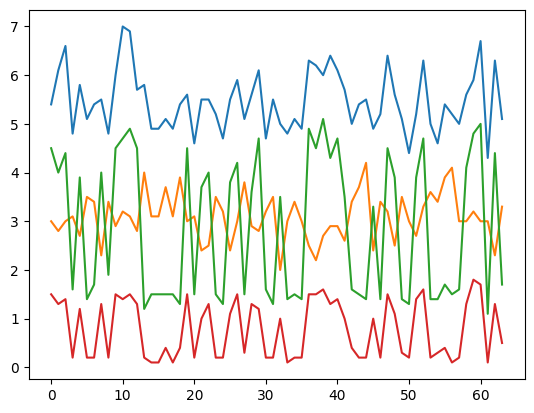

In [82]:
plt.plot(X_train)

In [83]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


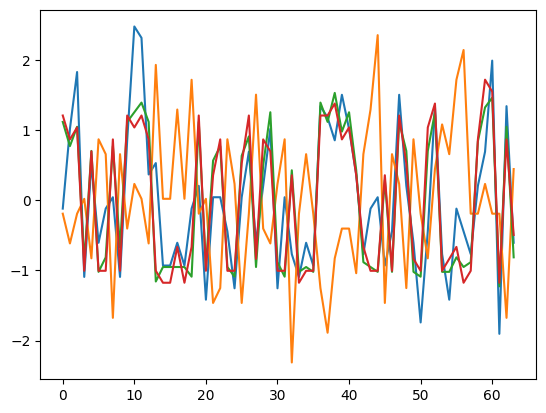

In [84]:
plt.plot(X_train)

In [85]:

class NeuralNet:
    def __init__(self, x, y, lr=0.3, epochs=2000):
        self.features = x                    
        self.labels = y                   
        self.lr = lr
        self.epochs = epochs
        # Initialize weights
        self.w1 = np.random.rand(4, 6)
        self.w2 = np.random.rand(6, 1)
        # Initialize biases
        self.b1 = np.random.rand(1, 6)
        self.b2 = np.random.rand(1, 1)
        self.costlist = []

    def sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def cost(self, y_t, y_o):
        return 0.5 * np.mean((y_t - y_o) ** 2)

    def forward(self, X):
        # Input → Hidden
        self.z1 = np.dot(X, self.w1) + self.b1    # (n,6)
        self.a1 = self.sigmoid(self.z1)           # (n,6)
        
        self.z2 = np.dot(self.a1, self.w2) + self.b2  # (n,1)
        self.a2 = self.sigmoid(self.z2)              # (n,1)
        return self.a2

    def backprop(self):
        error_output = (self.labels - self.a2) * self.sigmoid_derivative(self.a2)  
        # (n,1)
        error_hidden = (error_output.dot(self.w2.T) *
                        self.sigmoid_derivative(self.a1))                     # (n,6)

        # Gradients
        d_w2 = self.a1.T.dot(error_output)   # (6,1)
        d_w1 = self.features.T.dot(error_hidden)     # (4,6)
        d_b2 = np.sum(error_output, axis=0, keepdims=True)  # (1,1)
        d_b1 = np.sum(error_hidden, axis=0, keepdims=True)  # (1,6)

        # Update
        self.w2 += self.lr * d_w2
        self.w1 += self.lr * d_w1
        self.b2 += self.lr * d_b2
        self.b1 += self.lr * d_b1

    def train(self):
        for epoch in range(1, self.epochs + 1):
            self.forward(self.features)
            self.backprop()
            c = self.cost(self.labels, self.a2)
            self.costlist.append(c)
            if epoch % 10 == 0 or epoch == 1:
                print(f"Epoch {epoch:4d}  Cost: {c:.6f}")

    def predict(self, X_new):
        a2 = self.forward(X_new)
        return a2
    
    


Epoch    1  Cost: 0.173419
Epoch   10  Cost: 0.004005
Epoch   20  Cost: 0.001783
Epoch   30  Cost: 0.001119
Epoch   40  Cost: 0.000808
Epoch   50  Cost: 0.000629
Epoch   60  Cost: 0.000514
Epoch   70  Cost: 0.000433
Epoch   80  Cost: 0.000374
Epoch   90  Cost: 0.000329
Epoch  100  Cost: 0.000293
Epoch  110  Cost: 0.000264
Epoch  120  Cost: 0.000240
Epoch  130  Cost: 0.000220
Epoch  140  Cost: 0.000204
Epoch  150  Cost: 0.000189
Epoch  160  Cost: 0.000176
Epoch  170  Cost: 0.000165
Epoch  180  Cost: 0.000155
Epoch  190  Cost: 0.000147
Epoch  200  Cost: 0.000139
Epoch  210  Cost: 0.000132
Epoch  220  Cost: 0.000125
Epoch  230  Cost: 0.000120
Epoch  240  Cost: 0.000114
Epoch  250  Cost: 0.000109
Epoch  260  Cost: 0.000105
Epoch  270  Cost: 0.000101
Epoch  280  Cost: 0.000097
Epoch  290  Cost: 0.000094
Epoch  300  Cost: 0.000090
Epoch  310  Cost: 0.000087
Epoch  320  Cost: 0.000084
Epoch  330  Cost: 0.000082
Epoch  340  Cost: 0.000079
Epoch  350  Cost: 0.000077
Epoch  360  Cost: 0.000074
E

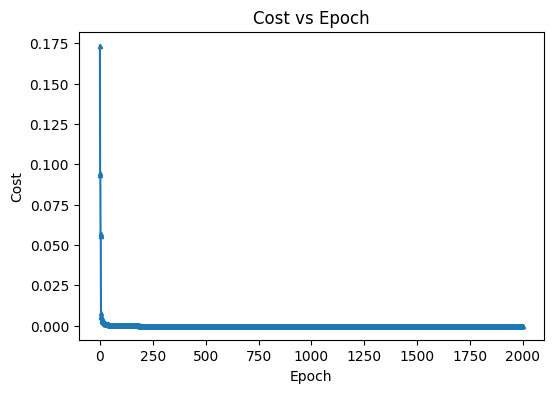

In [86]:
nn = NeuralNet(X_train, y_train, lr=0.3, epochs=2000)
nn.train()
y_pred_t = nn.predict(X_test) 
y_pred_label = np.where(y_pred_t < 0.5, "Iris-setosa", "Iris-versicolor")

plt.figure(figsize=(6,4))
plt.plot(nn.costlist, marker='^', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Cost vs Epoch")
plt.show()





In [87]:
def change_label(val):
    if val == 0.0001:
        return "Iris-setosa"
    else:
        return "Iris-versicolor"
    
y_pred_label

y_test_label = np.vectorize(change_label)(y_test)

In [88]:
def accuracy (y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    return correct / total * 100

acc=accuracy(y_test_label, y_pred_label)
print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 100.00%


In [89]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_label, y_pred_label))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         8
Iris-versicolor       1.00      1.00      1.00         8

       accuracy                           1.00        16
      macro avg       1.00      1.00      1.00        16
   weighted avg       1.00      1.00      1.00        16



In [90]:

confusion_matrix(y_test_label, y_pred_label)

array([[8, 0],
       [0, 8]], dtype=int64)